# Part A: Sentiment Analysis with RNN/LSTM

## Step 1: Data Preparation

In [1]:
import os
import tarfile
import urllib.request

# --- Step 1: Download & Extract ---
url = "http://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"
filename = "aclImdb_v1.tar.gz"

# Check if folder exists
if not os.path.exists("aclImdb"):
    if not os.path.exists(filename):
        print("Downloading IMDB dataset ... this might take a minute.")
        urllib.request.urlretrieve(url, filename)
        print("Download complete.")
    
    print("Extracting files... (this takes a moment)")
    with tarfile.open(filename, "r:gz") as tar:
        tar.extractall()
    print("Extraction complete.")
else:
    print("IMDB dataset already found.")

IMDB dataset already found.


## Step 2: Vocabulary & Text Processing

In [2]:
import re

# --- 1. Load Vocabulary ---
vocab_file = "aclImdb/imdb.vocab"
print(f"Loading vocabulary from {vocab_file}...")

with open(vocab_file, "r", encoding="utf-8") as f:
    # Read lines and strip whitespace
    vocab_list = [line.strip() for line in f.readlines()]

# --- 2. Build Dictionary ---
# We start indices at 2, reserving 0 and 1 for special tokens
word_to_idx = {word: i + 2 for i, word in enumerate(vocab_list)}

# Add special tokens manually
word_to_idx["<PAD>"] = 0  # Padding
word_to_idx["<UNK>"] = 1  # Unknown word

print(f"Vocabulary Size: {len(word_to_idx)}")
print(f"Index for 'movie': {word_to_idx.get('movie')}")
print(f"Index for 'terrible': {word_to_idx.get('terrible')}")


# --- 3. Text Cleaner Function ---
def clean_and_tokenize(text):
    """
    Cleans raw text and returns a list of word indices.
    """
    # Lowercase
    text = text.lower()
    # Remove HTML breaks <br />
    text = re.sub(r"<br />", " ", text)
    # Remove non-alphanumeric characters (keep only a-z and 0-9)
    text = re.sub(r"[^a-z0-9\s]", "", text)

    # Split into words
    tokens = text.split()

    # Convert to indices
    # If a word is not in vocab, use 1 (<UNK>)
    indices = [word_to_idx.get(w, 1) for w in tokens]

    return indices


# Test the cleaner
sample_text = "This movie was <br /> TERRIBLE!!"
print(f"\nOriginal: {sample_text}")
print(f"Indices:  {clean_and_tokenize(sample_text)}")

Loading vocabulary from aclImdb/imdb.vocab...
Vocabulary Size: 89529
Index for 'movie': 17
Index for 'terrible': 375

Original: This movie was <br /> TERRIBLE!!
Indices:  [11, 17, 13, 375]


## Step 3: Loading and Padding the Data

In [3]:
import matplotlib.pyplot as plt

# 1. Get lengths of all training reviews
lengths = []
for label in ["pos", "neg"]:
    path = f"aclImdb/train/{label}"
    for fname in os.listdir(path):
        with open(os.path.join(path, fname), 'r', encoding='utf-8') as f:
            # simple split to count words
            lengths.append(len(f.read().split()))

# 2. Calculate Stats
lengths.sort()
avg_len = sum(lengths) / len(lengths)
median_len = lengths[len(lengths)//2]
percentile_90 = lengths[int(len(lengths)*0.9)]

print(f"Average Review Length: {avg_len:.0f} words")
print(f"Median Review Length:  {median_len} words")
print(f"90% of reviews are under: {percentile_90} words")

Average Review Length: 234 words
Median Review Length:  174 words
90% of reviews are under: 458 words


In [4]:
import torch
import os

MAX_LEN = 400


def load_data(root_dir):
    data_list = []
    print(f"Scanning {root_dir}...")

    # Iterate through 'pos' (label=1.0) and 'neg' (label=0.0) folders
    for label_name, label_score in [("pos", 1.0), ("neg", 0.0)]:
        folder_path = os.path.join(root_dir, label_name)

        # Look at every text file in the folder
        for fname in os.listdir(folder_path):
            if fname.endswith(".txt"):
                path = os.path.join(folder_path, fname)

                # 1. Read the text
                with open(path, "r", encoding="utf-8") as f:
                    # turn text into a list of ints
                    indices = clean_and_tokenize(f.read())

                # 2. Pad or Truncate to MAX_LEN
                if len(indices) < MAX_LEN:
                    # Pad with 0s (indices + [0, 0, 0...])
                    indices += [0] * (MAX_LEN - len(indices))
                else:
                    # Cut off extra words
                    indices = indices[:MAX_LEN]

                # 3. Convert to PyTorch Tensors
                x_tensor = torch.tensor(indices, dtype=torch.long)
                y_tensor = torch.tensor(label_score, dtype=torch.float)

                data_list.append((x_tensor, y_tensor))

    return data_list


# --- Run the Loader ---
train_data = load_data("aclImdb/train")
test_data = load_data("aclImdb/test")

print(f"\nLoaded {len(train_data)} training samples.")
print(f"Loaded {len(test_data)} test samples.")

# Verify one sample
sample_x, sample_y = train_data[0]
print(f"Sample Shape: {sample_x.shape}")
print(f"Sample Label: {sample_y}")  # Should be 1.0 or 0.0

Scanning aclImdb/train...
Scanning aclImdb/test...

Loaded 25000 training samples.
Loaded 25000 test samples.
Sample Shape: torch.Size([400])
Sample Label: 1.0


## Step 4: Batching

In [5]:
from torch.utils.data import TensorDataset, DataLoader
import os

# 1. Unzip the data into two separate stacks: X (inputs) and Y (labels)
print("Stacking Tensors...")
train_x = torch.stack([item[0] for item in train_data])
train_y = torch.stack([item[1] for item in train_data])

test_x = torch.stack([item[0] for item in test_data])
test_y = torch.stack([item[1] for item in test_data])

# 2. Wrap them in a Dataset
train_ds = TensorDataset(train_x, train_y)
test_ds = TensorDataset(test_x, test_y)

# 3. Create Loaders with Multiprocessing
BATCH_SIZE = 64
NUM_WORKERS = 4  # Allows parallel data loading

# We use pin_memory=True to speed up transfer to CUDA (GPU)
train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
)

print(f"\nData Loaders ready with {NUM_WORKERS} workers.")
print(f"Train Batch Shape: {next(iter(train_loader))[0].shape}")

Stacking Tensors...

Data Loaders ready with 4 workers.
Train Batch Shape: torch.Size([64, 400])


## Step 5: Creating The Model

In [6]:
import torch.nn as nn
import torch.optim as optim


class SentimentLSTM(nn.Module):
    def __init__(
        self, vocab_size, embed_dim, hidden_dim, output_dim, n_layers, dropout
    ):
        super(SentimentLSTM, self).__init__()

        # 1. Embedding Layer
        # Converts integers (indexes) into dense vectors
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        # 2. LSTM Layer
        # bidirectional=True doubles the hidden dimension (Forward + Backward)
        # batch_first=True expects input shape: [batch_size, seq_len]
        self.lstm = nn.LSTM(
            embed_dim,
            hidden_dim,
            num_layers=n_layers,
            bidirectional=True,
            dropout=dropout,
            batch_first=True,
        )

        # 3. Fully Connected (Linear) Layer
        # Input size is hidden_dim * 2 because we concatenate Forward + Backward states
        self.fc = nn.Linear(hidden_dim * 2, output_dim)

        # 4. Activation Function
        self.sigmoid = nn.Sigmoid()

    def forward(self, text):
        # text shape: [batch_size, seq_len]

        # 1. Apply Embedding
        embedded = self.embedding(text)

        # 2. Apply LSTM
        # output: features for every word in sequence
        # hidden: final hidden state (summary)
        output, (hidden, cell) = self.lstm(embedded)

        # 3. Extract the final Forward and Backward hidden states
        # hidden shape: [layers*directions, batch, hidden_dim]
        # We take the last layer's forward (-2) and backward (-1) states
        hidden_forward = hidden[-2, :, :]
        hidden_backward = hidden[-1, :, :]

        # Concatenate them side-by-side
        cat_hidden = torch.cat((hidden_forward, hidden_backward), dim=1)

        # 4. Classification
        return self.sigmoid(self.fc(cat_hidden))


# --- Configuration & Instantiation ---
VOCAB_SIZE = len(word_to_idx)
EMBED_DIM = 100
HIDDEN_DIM = 256
OUTPUT_DIM = 1
N_LAYERS = 2
DROPOUT = 0.5

# Detect device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Model will run on: {device}")

# Create the model instance
model = SentimentLSTM(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, OUTPUT_DIM, N_LAYERS, DROPOUT)
model = model.to(device)  # Move the entire model to GPU/CPU

print(f'Model: {model}')

# --- Optimizer & Loss ---
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
criterion = nn.BCELoss().to(device)

print("\nReady.")

Model will run on: cuda
Model: SentimentLSTM(
  (embedding): Embedding(89529, 100, padding_idx=0)
  (lstm): LSTM(100, 256, num_layers=2, batch_first=True, dropout=0.5, bidirectional=True)
  (fc): Linear(in_features=512, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

Ready.


## Step 6: Training

Starting training with Early Stopping (Patience=3)...
Epoch 01: New Best Val Loss: 0.694 (Saved)
Epoch 01 | Time: 0m 53s
	Train Loss: 0.673 | Train Acc: 57.95%
	 Val. Loss: 0.694 |  Val. Acc: 51.26%
Epoch 02: New Best Val Loss: 0.686 (Saved)
Epoch 02 | Time: 0m 48s
	Train Loss: 0.655 | Train Acc: 59.72%
	 Val. Loss: 0.686 |  Val. Acc: 55.26%
Epoch 03: New Best Val Loss: 0.549 (Saved)
Epoch 03 | Time: 0m 45s
	Train Loss: 0.623 | Train Acc: 65.67%
	 Val. Loss: 0.549 |  Val. Acc: 73.83%
Epoch 04: New Best Val Loss: 0.388 (Saved)
Epoch 04 | Time: 0m 45s
	Train Loss: 0.449 | Train Acc: 79.60%
	 Val. Loss: 0.388 |  Val. Acc: 83.02%
Epoch 05: New Best Val Loss: 0.329 (Saved)
Epoch 05 | Time: 0m 45s
	Train Loss: 0.301 | Train Acc: 88.10%
	 Val. Loss: 0.329 |  Val. Acc: 86.17%
Epoch 06: New Best Val Loss: 0.320 (Saved)
Epoch 06 | Time: 0m 44s
	Train Loss: 0.226 | Train Acc: 91.52%
	 Val. Loss: 0.320 |  Val. Acc: 86.95%
Epoch 07: No improvement. Patience 1/3
Epoch 07 | Time: 0m 44s
	Train Loss: 

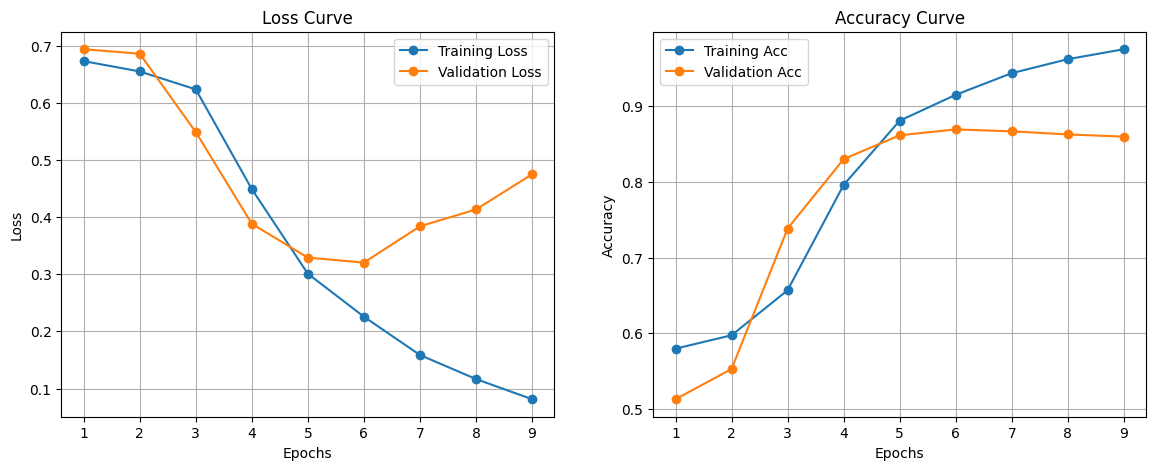

In [7]:
import time
import matplotlib.pyplot as plt


def binary_accuracy(preds, y):
    """
    Returns accuracy per batch, i.e. if you get 8/10 right, this returns 0.8
    """
    # Round predictions to the closest integer (0 or 1)
    rounded_preds = torch.round(preds)
    correct = (rounded_preds == y).float()
    acc = correct.sum() / len(correct)
    return acc


def train(model, loader, optimizer, criterion):
    # 1. Set the model to "Training Mode"
    # This turns ON Dropout (random noise) for regularization
    model.train()

    epoch_loss = 0
    epoch_acc = 0

    for batch_x, batch_y in loader:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        # 2. Zero Gradients (Reset previous calculations)
        optimizer.zero_grad()

        # 3. Forward Pass
        # We pass the batch into the model object directly
        # .squeeze(1) removes the extra dimension: [64, 1] -> [64]
        predictions = model(batch_x).squeeze(1)

        # 4. Calculate Loss & Accuracy
        loss = criterion(predictions, batch_y)
        acc = binary_accuracy(predictions, batch_y)

        # 5. Backward Pass (Calculate Gradients)
        loss.backward()

        # 6. Optimization Step (Update Weights)
        optimizer.step()

        epoch_loss += loss.item()
        epoch_acc += acc.item()

    return epoch_loss / len(loader), epoch_acc / len(loader)


def evaluate(model, loader, criterion):
    # 1. Set the model to "Evaluation Mode"
    # This turns OFF Dropout so we get stable predictions
    model.eval()

    epoch_loss = 0
    epoch_acc = 0

    # 2. Disable Gradient Calculation
    # We don't need to update weights here
    with torch.no_grad():
        for batch_x, batch_y in loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)

            predictions = model(batch_x).squeeze(1)

            loss = criterion(predictions, batch_y)
            acc = binary_accuracy(predictions, batch_y)

            epoch_loss += loss.item()
            epoch_acc += acc.item()

    return epoch_loss / len(loader), epoch_acc / len(loader)


# --- Configuration ---
N_EPOCHS = 20
PATIENCE = 3
best_val_loss = float("inf")
patience_counter = 0

# History storage
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

print(f"Starting training with Early Stopping (Patience={PATIENCE})...")

for epoch in range(N_EPOCHS):
    start_time = time.time()

    # 1. Train & Evaluate
    train_loss, train_acc = train(model, train_loader, optimizer, criterion)
    valid_loss, valid_acc = evaluate(model, test_loader, criterion)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(valid_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(valid_acc)

    # 2. Early Stopping
    if valid_loss < best_val_loss:
        # A. IMPROVEMENT FOUND
        best_val_loss = valid_loss
        patience_counter = 0  # Reset the counter

        # Save the best model to disk
        torch.save(model.state_dict(), "best_sentiment_model.pth")
        print(f"Epoch {epoch+1:02}: New Best Val Loss: {valid_loss:.3f} (Saved)")

    else:
        # B. NO IMPROVEMENT
        patience_counter += 1
        print(
            f"Epoch {epoch+1:02}: No improvement. Patience {patience_counter}/{PATIENCE}"
        )

    end_time = time.time()
    mins, secs = divmod(end_time - start_time, 60)

    # Print stats
    print(f"Epoch {epoch+1:02} | Time: {int(mins)}m {int(secs)}s")
    print(f"\tTrain Loss: {train_loss:.3f} | Train Acc: {train_acc*100:.2f}%")
    print(f"\t Val. Loss: {valid_loss:.3f} |  Val. Acc: {valid_acc*100:.2f}%")

    # 3. Check Trigger
    if patience_counter >= PATIENCE:
        print(f"\nEarly Stopping triggered! Stopping at Epoch {epoch+1}")
        break

# --- Load the Best Version ---
print("\nLoading the best model weights...")
model.load_state_dict(torch.load("best_sentiment_model.pth"))
print("Model restored to best state.")

# --- Plotting the Curves ---
epochs_range = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(14, 5))

# Plot 1: Loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history["train_loss"], label="Training Loss", marker="o")
plt.plot(epochs_range, history["val_loss"], label="Validation Loss", marker="o")
plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# Plot 2: Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history["train_acc"], label="Training Acc", marker="o")
plt.plot(epochs_range, history["val_acc"], label="Validation Acc", marker="o")
plt.title("Accuracy Curve")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

Testing the model

In [8]:
def predict_sentiment(sentence):
    # 1. Set model to evaluation mode
    model.eval()

    # 2. Clean and Tokenize (reusing the function from Step 2)
    # This turns "I love this!" into [10, 439, 11...]
    indices = clean_and_tokenize(sentence)

    # 3. Handle Length (Pad or Truncate to 400)
    if len(indices) < MAX_LEN:
        indices += [0] * (MAX_LEN - len(indices))
    else:
        indices = indices[:MAX_LEN]

    # 4. Convert to Tensor & Add Batch Dimension
    # Shape becomes [1, 400] because the model expects a batch
    tensor = torch.tensor(indices, dtype=torch.long).unsqueeze(0).to(device)

    # 5. Predict
    prediction = model(tensor)
    score = prediction.item()

    # 6. Print Result
    status = "POSITIVE" if score > 0.5 else "NEGATIVE"
    print(f"Review: '{sentence}'")
    print(f"Score:  {score:.4f} ({status})\n")


for file_name in [
    "./aclImdb/test/pos/0_10.txt",
    "./aclImdb/test/pos/1_10.txt",
    "./aclImdb/test/neg/0_2.txt",
    "./aclImdb/test/neg/1_3.txt",
]:
    with open(file_name, "r", encoding="utf-8") as f:
        review_text = f.read()
        predict_sentiment(review_text)

Review: 'I went and saw this movie last night after being coaxed to by a few friends of mine. I'll admit that I was reluctant to see it because from what I knew of Ashton Kutcher he was only able to do comedy. I was wrong. Kutcher played the character of Jake Fischer very well, and Kevin Costner played Ben Randall with such professionalism. The sign of a good movie is that it can toy with our emotions. This one did exactly that. The entire theater (which was sold out) was overcome by laughter during the first half of the movie, and were moved to tears during the second half. While exiting the theater I not only saw many women in tears, but many full grown men as well, trying desperately not to let anyone see them crying. This movie was great, and I suggest that you go see it before you judge.'
Score:  0.9614 (POSITIVE)

Review: 'My boyfriend and I went to watch The Guardian.At first I didn't want to watch it, but I loved the movie- It was definitely the best movie I have seen in someti

## Step 7: Saving the model

In [9]:
# 1. Define the bundle
checkpoint = {
    "state_dict": model.state_dict(),
    "vocab": word_to_idx,
    "config": {
        "vocab_size": VOCAB_SIZE,
        "embed_dim": EMBED_DIM,
        "hidden_dim": HIDDEN_DIM,
        "output_dim": OUTPUT_DIM,
        "n_layers": N_LAYERS,
        "dropout": DROPOUT,
    },
}

# 2. Save it
print("Saving complete model bundle...")
torch.save(checkpoint, "sentiment_classifier_complete.pth")
print("Saved to 'sentiment_classifier_complete.pth'")

Saving complete model bundle...
Saved to 'sentiment_classifier_complete.pth'


In [10]:
# --- SIMULATING A FRESH START ---

def load_and_predict(text, model_path):
    # 1. Load the file
    print(f"Loading {model_path}...")
    checkpoint = torch.load(model_path, map_location=device)

    # 2. Extract Data
    vocab = checkpoint["vocab"]
    config = checkpoint["config"]
    state_dict = checkpoint["state_dict"]

    # 3. Rebuild the Model Structure
    # We use the 'config' dict to ensure the dimensions match exactly
    loaded_model = SentimentLSTM(
        vocab_size=config["vocab_size"],
        embed_dim=config["embed_dim"],
        hidden_dim=config["hidden_dim"],
        output_dim=config["output_dim"],
        n_layers=config["n_layers"],
        dropout=config["dropout"],
    )

    # 4. Load the Weights
    loaded_model.load_state_dict(state_dict)
    loaded_model.to(device)
    loaded_model.eval()

    # 5. Preprocessing (Internal Function)
    # We must recreate the tokenization logic using the LOADED vocab
    # (Simplified version of clean_and_tokenize)
    import re

    text = text.lower()
    text = re.sub(r"<br />", " ", text)
    text = re.sub(r"[^a-z0-9\s]", "", text)
    tokens = text.split()

    # Convert to indices
    indices = [vocab.get(t, vocab.get("<unk>", 0)) for t in tokens]

    # Pad/Truncate to 400
    if len(indices) < 400:
        indices += [0] * (400 - len(indices))
    else:
        indices = indices[:400]

    # 6. Predict
    tensor = torch.tensor(indices, dtype=torch.long).unsqueeze(0).to(device)
    prediction = loaded_model(tensor).item()

    status = "POSITIVE" if prediction > 0.5 else "NEGATIVE"
    print(f"Input: '{text}'")
    print(f"Prediction: {prediction:.4f} ({status})\n")


# --- Test the Reloaded Model ---
load_and_predict(
    "This is the best movie I have seen in years.", "sentiment_classifier_complete.pth"
)
load_and_predict(
    "Don't waste your time, it is garbage.", "sentiment_classifier_complete.pth"
)

Loading sentiment_classifier_complete.pth...
Input: 'this is the best movie i have seen in years'
Prediction: 0.9890 (POSITIVE)

Loading sentiment_classifier_complete.pth...
Input: 'dont waste your time it is garbage'
Prediction: 0.1490 (NEGATIVE)



## Step 8: Evaluating

Generating predictions for the test set...

CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Negative       0.88      0.85      0.87     12500
    Positive       0.86      0.89      0.87     12500

    accuracy                           0.87     25000
   macro avg       0.87      0.87      0.87     25000
weighted avg       0.87      0.87      0.87     25000



<Figure size 800x600 with 0 Axes>

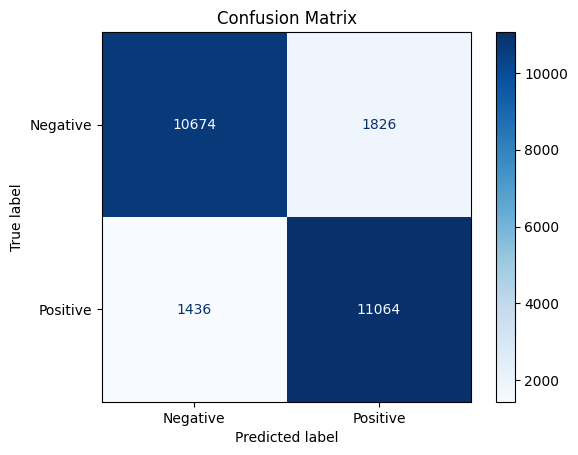

In [12]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)


def evaluate_metrics(model, loader):
    model.eval()

    # Store all results here
    y_true = []
    y_pred_probs = []

    print("Generating predictions for the test set...")

    with torch.no_grad():
        for batch_x, batch_y in loader:
            batch_x = batch_x.to(device)

            # Get probabilities
            predictions = model(batch_x).squeeze(1)

            # Move to CPU and convert to numpy for Scikit-Learn
            y_pred_probs.extend(predictions.cpu().numpy())
            y_true.extend(batch_y.cpu().numpy())

    # Convert probabilities to binary class labels (0 or 1)
    # Threshold is 0.5: > 0.5 is Positive, < 0.5 is Negative
    y_pred_labels = [1 if p > 0.5 else 0 for p in y_pred_probs]

    # --- 1. Text Report (Precision, Recall, F1) ---
    print("\n" + "=" * 50)
    print("CLASSIFICATION REPORT")
    print("=" * 50)
    print(
        classification_report(
            y_true, y_pred_labels, target_names=["Negative", "Positive"]
        )
    )

    # --- 2. Confusion Matrix Plot ---
    cm = confusion_matrix(y_true, y_pred_labels)

    plt.figure(figsize=(8, 6))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm, display_labels=["Negative", "Positive"]
    )
    disp.plot(cmap="Blues", values_format="d")
    plt.title("Confusion Matrix")
    plt.show()


# Run the evaluation
evaluate_metrics(model, test_loader)

# Part B: Named Entity Recognition